 # 07 — Gaussian Smoothing Sensitivity Analysis



 This notebook evaluates whether Gaussian smoothing improves selected final

 functional classifiers from the thesis-ready model set.



 The notebook intentionally keeps the model set small and directly comparable

 to notebook 04.



 Compared representations:

 - raw / unsmoothed L2-normalised sampled spectra

 - Gaussian-smoothed sampled spectra with sigma = 2, 4, 6 followed by L2 normalisation



 Compared models:

 - weighted kNN + standardized Euclidean distance

 - functional logistic regression (L2)

 - functional linear SVM



 Main outputs:

 - smoothing_fold_metrics.csv

 - smoothing_summary.csv

 - smoothing_delta_sigma_minus_raw.csv

 - smoothing_wilcoxon.csv

 - smoothing_interpretability_payload.npz

 - SVG interpretability figures

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import wilcoxon

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



 ## 1. Configuration

In [2]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "07_smoothing"
FIG_DIR = OUT_DIR 

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = False

SIGMAS = [0.0, 2.0, 4.0, 6.0]
BEST_SIGMA = 6.0

DISTANCE_K = 5

INNER_CV = 3
CS_GRID = np.logspace(-2, 2, 6)

LINEAR_MODELS = [
    {
        "family": "Functional linear",
        "method": "Functional logistic regression (L2)",
        "kind": "logreg_l2",
    },
    {
        "family": "Functional linear",
        "method": "Functional linear SVM",
        "kind": "linear_svm",
    },
]

# Plot styling
COLOR_RAW = "#104A7E" 
COLOR_SMOOTH = "#78003F"
COLOR_DARK = "#0D1530"
COLOR_GREY = "#8C8C8C"
COLOR_POS = "#6193CD"
COLOR_NEG = "#6F0037"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
})



 ## 2. Helper functions

In [3]:
def find_first_existing(paths: list[Path]) -> Path | None:
    for p in paths:
        if p.exists():
            return p
    return None


def split_sort_key(k: str) -> tuple[int, int]:
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)


def ms(mean, std):
    if pd.isna(mean):
        return np.nan
    return f"{mean:.4f} ± {0.0 if pd.isna(std) else std:.4f}"


def l2_normalise_rows(X: np.ndarray) -> np.ndarray:
    row_norm = np.linalg.norm(X, axis=1, keepdims=True)
    return np.divide(X, row_norm, out=np.zeros_like(X), where=row_norm > 1e-20)


def gaussian_smoothing_matrix(wavelengths: np.ndarray, sigma: float) -> np.ndarray:
    W = np.exp(
        -0.5 * ((wavelengths[:, None] - wavelengths[None, :]) / sigma) ** 2
    )
    W /= W.sum(axis=1, keepdims=True)
    return W


def build_representation(X_raw: np.ndarray, wavelengths: np.ndarray, sigma: float) -> np.ndarray:
    if sigma == 0:
        X_work = X_raw.copy()
    else:
        W = gaussian_smoothing_matrix(wavelengths, sigma)
        X_work = X_raw @ W.T

    return l2_normalise_rows(X_work)


def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo = float(np.min(scores_tr))
    hi = float(np.max(scores_tr))

    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)

    out = (scores_te - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float64)


def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)

    best_j = -1.0
    best_thr = 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0

        if j > best_j:
            best_j = j
            best_thr = float(thr)

    return best_thr


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict:
    out = {"pr_auc": average_precision_score(y_true_te, y_score_te)}

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)

    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out


def summarise_run(df_run: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = [
        "pr_auc",
        "roc_auc",
        "sensitivity",
        "precision",
        "specificity",
        "accuracy",
        "f1",
        "youden_j",
        "youden_threshold",
    ]

    agg_dict = {}
    for m in metric_cols:
        agg_dict[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
        agg_dict[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


def apply_clean_axes(ax, add_grid: bool = False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(alpha=0.20, linewidth=0.7)
    else:
        ax.grid(False)

    return ax



 ## 3. Locate and load core files

In [4]:
LABEL_FILE = find_first_existing([BASE_DIR / "og_xp.csv"])
SPLIT_FILE = find_first_existing([BASE_DIR / "splits_rskf.json"])
SAMPLED_FILE = find_first_existing([BASE_DIR / "xp_sampled_spectra.csv"])

if LABEL_FILE is None:
    raise FileNotFoundError("Missing og_xp.csv")
if SPLIT_FILE is None:
    raise FileNotFoundError("Missing splits_rskf.json")
if SAMPLED_FILE is None:
    raise FileNotFoundError("Missing xp_sampled_spectra.csv")

print("LABEL_FILE:", LABEL_FILE)
print("SPLIT_FILE:", SPLIT_FILE)
print("SAMPLED_FILE:", SAMPLED_FILE)



LABEL_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
SPLIT_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\splits_rskf.json
SAMPLED_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv


In [5]:
df_labels = pd.read_csv(LABEL_FILE)
df_spec = pd.read_csv(SAMPLED_FILE)

if "source_id" not in df_labels.columns or "y" not in df_labels.columns:
    raise ValueError("og_xp.csv must contain source_id and y")

if "source_id" not in df_spec.columns:
    raise ValueError("xp_sampled_spectra.csv must contain source_id")

wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
if len(wl_cols) == 0:
    raise ValueError("No sampled spectrum columns found. Expected wl_* columns.")

wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)

df_m = df_labels[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

X_raw = df_m[wl_cols].to_numpy(dtype=np.float64)
y = df_m["y"].to_numpy(dtype=np.int64)

with open(SPLIT_FILE) as f:
    splits = json.load(f)

split_names = sorted(splits.keys(), key=split_sort_key)

if SMOKE:
    split_names = [k for k in split_names if k.startswith("rep0_")]

print("Merged rows:", len(df_m))
print("X_raw shape:", X_raw.shape)
print("Binary fraction:", round((y == 1).mean(), 4))
print("Number of splits:", len(split_names))
print("Wavelength range:", wavelengths.min(), "to", wavelengths.max())



Merged rows: 2815
X_raw shape: (2815, 343)
Binary fraction: 0.1982
Number of splits: 50
Wavelength range: 336.0 to 1020.0


 ## 4. Build raw and smoothed representations



 Important:



 - sigma = 0 means no smoothing;

 - sigma = 2 means Gaussian smoothing on raw flux values;

 - L2 normalisation is applied after smoothing.

In [6]:
X_by_sigma = {}

for sigma in SIGMAS:
    X_by_sigma[sigma] = build_representation(X_raw, wavelengths, sigma)
    print(f"sigma={sigma}: shape={X_by_sigma[sigma].shape}")



sigma=0.0: shape=(2815, 343)
sigma=2.0: shape=(2815, 343)
sigma=4.0: shape=(2815, 343)
sigma=6.0: shape=(2815, 343)


 ## 5. Distance-based model: weighted kNN + standardized Euclidean

In [7]:
def train_seuclidean_params(X_tr: np.ndarray) -> dict:
    V = np.var(X_tr, axis=0, ddof=1)
    V = np.where(V <= 1e-12, 1e-12, V)
    return {"distance": "seuclidean", "V": V}


def pairwise_seuclidean(X_a: np.ndarray, X_b: np.ndarray, params: dict) -> np.ndarray:
    return pairwise_distances(X_a, X_b, metric="seuclidean", V=params["V"])


def knn_scores_from_distances(
    D: np.ndarray,
    y_ref: np.ndarray,
    k: int,
    weighted: bool = True,
    exclude_self: bool = False,
) -> np.ndarray:
    D = D.copy()

    if exclude_self and D.shape[0] == D.shape[1]:
        np.fill_diagonal(D, np.inf)

    nn_idx = np.argsort(D, axis=1)[:, :k]
    nn_d = np.take_along_axis(D, nn_idx, axis=1)
    nn_y = y_ref[nn_idx]

    if weighted:
        w = 1.0 / np.maximum(nn_d, 1e-12)
        score = (w * nn_y).sum(axis=1) / w.sum(axis=1)
    else:
        score = nn_y.mean(axis=1)

    return score.astype(np.float64)


def run_weighted_knn_seuclidean_one_split(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
) -> dict:
    X_tr = X[train_idx]
    X_te = X[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    params = train_seuclidean_params(X_tr)

    D_tr = pairwise_seuclidean(X_tr, X_tr, params)
    D_te = pairwise_seuclidean(X_te, X_tr, params)

    score_tr = knn_scores_from_distances(
        D_tr,
        y_tr,
        k=DISTANCE_K,
        weighted=True,
        exclude_self=True,
    )

    score_te = knn_scores_from_distances(
        D_te,
        y_tr,
        k=DISTANCE_K,
        weighted=True,
        exclude_self=False,
    )

    return fold_metrics(y_te, score_te, y_tr, score_tr)



 ## 6. Functional linear model helpers

In [8]:
def mean_inner_cv_roc_auc_at_best_c(clf: LogisticRegressionCV) -> float:
    sc = clf.scores_

    if sc is None:
        return np.nan

    if isinstance(sc, dict):
        arr = np.asarray(next(iter(sc.values())))
    elif hasattr(sc, "ndim") and sc.ndim == 3:
        arr = sc[0]
    else:
        arr = np.asarray(sc)

    c_grid = np.asarray(clf.Cs_)
    best_c = float(clf.C_[0])
    j = int(np.argmin(np.abs(c_grid - best_c)))

    return float(np.mean(arr[:, j]))


def run_linear_model_one_split(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    kind: str,
) -> tuple[dict, np.ndarray]:
    X_tr = X[train_idx]
    X_te = X[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    if kind == "logreg_l2":
        model = LogisticRegressionCV(
            Cs=CS_GRID,
            cv=StratifiedKFold(
                n_splits=INNER_CV,
                shuffle=True,
                random_state=RANDOM_STATE,
            ),
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            scoring="roc_auc",
            max_iter=2000,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_s, y_tr)

        score_tr = model.predict_proba(X_tr_s)[:, 1]
        score_te = model.predict_proba(X_te_s)[:, 1]
        coef = model.coef_[0].copy()

        extra = {
            "best_C": float(model.C_[0]),
            "best_cv_roc_auc": mean_inner_cv_roc_auc_at_best_c(model),
            "n_nonzero_coefs": int(X.shape[1]),
        }

    elif kind == "linear_svm":
        inner_cv = StratifiedKFold(
            n_splits=INNER_CV,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        c_scores = []

        for C in CS_GRID:
            fold_scores = []

            for inner_tr, inner_va in inner_cv.split(X_tr_s, y_tr):
                clf = LinearSVC(
                    C=C,
                    class_weight="balanced",
                    max_iter=10000,
                    random_state=RANDOM_STATE,
                )

                clf.fit(X_tr_s[inner_tr], y_tr[inner_tr])
                va_score = clf.decision_function(X_tr_s[inner_va])

                try:
                    auc = roc_auc_score(y_tr[inner_va], va_score)
                except ValueError:
                    auc = np.nan

                fold_scores.append(auc)

            c_scores.append(np.nanmean(fold_scores))

        best_i = int(np.nanargmax(c_scores))
        best_c = float(CS_GRID[best_i])

        model = LinearSVC(
            C=best_c,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_s, y_tr)

        score_tr = model.decision_function(X_tr_s)
        score_te = model.decision_function(X_te_s)
        coef = model.coef_[0].copy()

        extra = {
            "best_C": best_c,
            "best_cv_roc_auc": float(c_scores[best_i]),
            "n_nonzero_coefs": int(np.sum(np.abs(coef) > 1e-12)),
        }

    else:
        raise ValueError(f"Unsupported kind: {kind}")

    metrics = fold_metrics(y_te, score_te, y_tr, score_tr)
    metrics.update(extra)

    return metrics, coef



 ## 7. Run selected models for raw and smoothed spectra

In [9]:
records = []
coef_store = {
    sigma: {cfg["method"]: [] for cfg in LINEAR_MODELS}
    for sigma in SIGMAS
}

for sigma in SIGMAS:
    X = X_by_sigma[sigma]
    representation = "Raw L2-normalised sampled spectra" if sigma == 0 else f"Gaussian-smoothed L2-normalised spectra, sigma={sigma:g}"

    print("\n" + "=" * 80)
    print(f"Representation: {representation}")
    print("=" * 80)

    for sname in split_names:
        print(f"Current fold: {sname}")

        tr_idx = np.array(splits[sname]["train"], dtype=int)
        te_idx = np.array(splits[sname]["test"], dtype=int)

        # weighted kNN + standardized Euclidean
        print("  -> weighted kNN + seuclidean")

        met = run_weighted_knn_seuclidean_one_split(
            X=X,
            y=y,
            train_idx=tr_idx,
            test_idx=te_idx,
        )

        row = {
            "split": sname,
            "sigma": sigma,
            "representation": representation,
            "family": "Distance-based functional",
            "method": "weighted kNN + seuclidean",
            "tuning": f"k={DISTANCE_K}",
        }
        row.update(met)
        records.append(row)

        # linear models
        for cfg in LINEAR_MODELS:
            print(f"  -> {cfg['method']}")

            met, coef = run_linear_model_one_split(
                X=X,
                y=y,
                train_idx=tr_idx,
                test_idx=te_idx,
                kind=cfg["kind"],
            )

            row = {
                "split": sname,
                "sigma": sigma,
                "representation": representation,
                "family": cfg["family"],
                "method": cfg["method"],
                "tuning": "inner-CV C",
            }
            row.update(met)

            records.append(row)
            coef_store[sigma][cfg["method"]].append(coef)

df_fold = pd.DataFrame(records)

print("\nFold metrics shape:", df_fold.shape)
display(df_fold.head())




Representation: Raw L2-normalised sampled spectra
Current fold: rep0_fold0
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold1
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold2
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold3
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold4
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold0
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold1
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold2
  -> weighted kNN + seuclidean
  -> Functional logistic 

,split,sigma,representation,family,method,tuning,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,f1,youden_j,best_C,best_cv_roc_auc,n_nonzero_coefs
0,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Distance-based functional,weighted kNN + seuclidean,k=5,0.883580,0.938771,0.211055,0.855856,0.798319,0.946903,0.928952,0.826087,0.802759,NaN,NaN,NaN
1,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional logistic regression (L2),inner-CV C,0.926838,0.959420,0.427136,0.882883,0.852174,0.962389,0.946714,0.867257,0.845272,0.01,0.900627,343.0
2,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional linear SVM,inner-CV C,0.929114,0.958602,0.135678,0.873874,0.815126,0.951327,0.936057,0.843478,0.825201,0.01,0.896827,343.0
3,rep0_fold1,0.0,Raw L2-normalised sampled spectra,Distance-based functional,weighted kNN + seuclidean,k=5,0.753877,0.848641,0.391960,0.684685,0.800000,0.957965,0.904085,0.737864,0.642649,NaN,NaN,NaN
4,rep0_fold1,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional logistic regression (L2),inner-CV C,0.804143,0.872040,0.467337,0.765766,0.801887,0.953540,0.916519,0.783410,0.719306,0.01,0.924836,343.0


 ## 8. Summary tables

In [10]:
df_summary = summarise_run(
    df_fold,
    ["sigma", "representation", "family", "method", "tuning"],
)

df_summary = df_summary.sort_values(
    ["method", "sigma"]
).reset_index(drop=True)

display(
    df_summary[
        [
            "sigma",
            "family",
            "method",
            "f1_mean",
            "f1_std",
            "pr_auc_mean",
            "pr_auc_std",
            "roc_auc_mean",
            "roc_auc_std",
            "sensitivity_mean",
            "specificity_mean",
        ]
    ]
)



,sigma,family,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,sensitivity_mean,specificity_mean
0,0.0,Functional linear,Functional linear SVM,0.806558,0.029996,0.865662,0.029136,0.915128,0.019686,0.824735,0.945282
1,2.0,Functional linear,Functional linear SVM,0.808954,0.030250,0.866837,0.028310,0.915847,0.019103,0.824014,0.947009
2,4.0,Functional linear,Functional linear SVM,0.806433,0.028336,0.868995,0.026788,0.917782,0.018068,0.827225,0.944349
3,6.0,Functional linear,Functional linear SVM,0.808628,0.029439,0.872742,0.025752,0.920879,0.017224,0.825087,0.946390
4,0.0,Functional linear,Functional logistic regression (L2),0.809755,0.027759,0.865020,0.028002,0.915473,0.019765,0.829204,0.945767
5,2.0,Functional linear,Functional logistic regression (L2),0.809701,0.029065,0.866019,0.027033,0.916076,0.018994,0.828488,0.945945
6,4.0,Functional linear,Functional logistic regression (L2),0.809419,0.025652,0.869020,0.026062,0.918929,0.018373,0.828845,0.945724
7,6.0,Functional linear,Functional logistic regression (L2),0.810899,0.027290,0.870786,0.025740,0.920457,0.017676,0.827762,0.946963
8,0.0,Distance-based functional,weighted kNN + seuclidean,0.773768,0.027378,0.808304,0.035406,0.891048,0.020077,0.776499,0.942927
9,2.0,Distance-based functional,weighted kNN + seuclidean,0.782634,0.029773,0.814213,0.034622,0.897276,0.019945,0.775071,0.949090


In [11]:
pretty_summary = pd.DataFrame({
    "Sigma": df_summary["sigma"],
    "Family": df_summary["family"],
    "Method": df_summary["method"],
    "F1 mean ± std": [ms(m, s) for m, s in zip(df_summary["f1_mean"], df_summary["f1_std"])],
    "PR-AUC mean ± std": [ms(m, s) for m, s in zip(df_summary["pr_auc_mean"], df_summary["pr_auc_std"])],
    "ROC-AUC mean ± std": [ms(m, s) for m, s in zip(df_summary["roc_auc_mean"], df_summary["roc_auc_std"])],
    "Sensitivity mean ± std": [ms(m, s) for m, s in zip(df_summary["sensitivity_mean"], df_summary["sensitivity_std"])],
    "Specificity mean ± std": [ms(m, s) for m, s in zip(df_summary["specificity_mean"], df_summary["specificity_std"])],
})

display(pretty_summary)



,Sigma,Family,Method,F1 mean ± std,PR-AUC mean ± std,ROC-AUC mean ± std,Sensitivity mean ± std,Specificity mean ± std
0,0.0,Functional linear,Functional linear SVM,0.8066 ± 0.0300,0.8657 ± 0.0291,0.9151 ± 0.0197,0.8247 ± 0.0316,0.9453 ± 0.0149
1,2.0,Functional linear,Functional linear SVM,0.8090 ± 0.0302,0.8668 ± 0.0283,0.9158 ± 0.0191,0.8240 ± 0.0320,0.9470 ± 0.0156
2,4.0,Functional linear,Functional linear SVM,0.8064 ± 0.0283,0.8690 ± 0.0268,0.9178 ± 0.0181,0.8272 ± 0.0333,0.9443 ± 0.0141
3,6.0,Functional linear,Functional linear SVM,0.8086 ± 0.0294,0.8727 ± 0.0258,0.9209 ± 0.0172,0.8251 ± 0.0276,0.9464 ± 0.0150
4,0.0,Functional linear,Functional logistic regression (L2),0.8098 ± 0.0278,0.8650 ± 0.0280,0.9155 ± 0.0198,0.8292 ± 0.0329,0.9458 ± 0.0129
5,2.0,Functional linear,Functional logistic regression (L2),0.8097 ± 0.0291,0.8660 ± 0.0270,0.9161 ± 0.0190,0.8285 ± 0.0321,0.9459 ± 0.0137
6,4.0,Functional linear,Functional logistic regression (L2),0.8094 ± 0.0257,0.8690 ± 0.0261,0.9189 ± 0.0184,0.8288 ± 0.0312,0.9457 ± 0.0117
7,6.0,Functional linear,Functional logistic regression (L2),0.8109 ± 0.0273,0.8708 ± 0.0257,0.9205 ± 0.0177,0.8278 ± 0.0307,0.9470 ± 0.0131
8,0.0,Distance-based functional,weighted kNN + seuclidean,0.7738 ± 0.0274,0.8083 ± 0.0354,0.8910 ± 0.0201,0.7765 ± 0.0402,0.9429 ± 0.0145
9,2.0,Distance-based functional,weighted kNN + seuclidean,0.7826 ± 0.0298,0.8142 ± 0.0346,0.8973 ± 0.0199,0.7751 ± 0.0362,0.9491 ± 0.0128


## 9. Delta tables: smoothed spectra minus raw spectra

In [12]:
metric_cols = [
    "pr_auc_mean",
    "roc_auc_mean",
    "sensitivity_mean",
    "precision_mean",
    "specificity_mean",
    "accuracy_mean",
    "f1_mean",
    "youden_j_mean",
]

raw_summary = df_summary[df_summary["sigma"] == 0.0].set_index("method")

delta_rows = []

for sigma in [s for s in SIGMAS if s != 0.0]:
    sm_summary = df_summary[df_summary["sigma"] == sigma].set_index("method")

    for method in raw_summary.index:
        if method not in sm_summary.index:
            continue

        row = {
            "sigma": sigma,
            "method": method,
            "family": raw_summary.loc[method, "family"],
        }

        for m in metric_cols:
            row[f"delta_{m.replace('_mean', '')}"] = (
                sm_summary.loc[method, m] - raw_summary.loc[method, m]
            )

        delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows)

display(df_delta.sort_values(["method", "sigma"]))

,sigma,method,family,delta_pr_auc,delta_roc_auc,delta_sensitivity,delta_precision,delta_specificity,delta_accuracy,delta_f1,delta_youden_j
0,2.0,Functional linear SVM,Functional linear,0.001175,0.000719,-0.000721,0.005465,0.001727,0.001243,0.002397,0.001006
3,4.0,Functional linear SVM,Functional linear,0.003333,0.002654,0.002490,-0.002456,-0.000933,-0.000249,-0.000125,0.001557
6,6.0,Functional linear SVM,Functional linear,0.007080,0.005751,0.000352,0.003591,0.001107,0.000959,0.002070,0.001459
1,2.0,Functional logistic regression (L2),Functional linear,0.000999,0.000603,-0.000716,0.000552,0.000178,0.000000,-0.000054,-0.000538
4,4.0,Functional logistic regression (L2),Functional linear,0.004000,0.003456,-0.000359,-0.000482,-0.000043,-0.000107,-0.000336,-0.000402
7,6.0,Functional logistic regression (L2),Functional linear,0.005765,0.004984,-0.001441,0.003504,0.001196,0.000675,0.001144,-0.000246
2,2.0,weighted kNN + seuclidean,Distance-based functional,0.005910,0.006228,-0.001429,0.018415,0.006163,0.004654,0.008865,0.004734
5,4.0,weighted kNN + seuclidean,Distance-based functional,0.017934,0.009796,0.012003,0.017036,0.004476,0.005968,0.014725,0.016479
8,6.0,weighted kNN + seuclidean,Distance-based functional,0.020149,0.012310,0.007366,0.043464,0.013030,0.011901,0.025651,0.020397


## 10. Wilcoxon signed-rank tests

Paired tests across identical CV folds:

- sigma = 2 vs raw
- sigma = 4 vs raw
- sigma = 6 vs raw

Metrics:
- F1
- PR-AUC

In [13]:
wilcoxon_rows = []
ALPHA = 0.05

for sigma in [s for s in SIGMAS if s != 0.0]:
    for method in sorted(df_fold["method"].unique()):
        for metric in ["f1", "pr_auc"]:

            raw_vals = (
                df_fold[
                    (df_fold["method"] == method)
                    & (df_fold["sigma"] == 0.0)
                ]
                .sort_values("split")[metric]
                .to_numpy()
            )

            sm_vals = (
                df_fold[
                    (df_fold["method"] == method)
                    & (df_fold["sigma"] == sigma)
                ]
                .sort_values("split")[metric]
                .to_numpy()
            )

            if len(raw_vals) != len(sm_vals) or len(raw_vals) == 0:
                stat = np.nan
                p_value = np.nan
                mean_raw = np.nan
                mean_smoothed = np.nan
                mean_delta = np.nan
                significant = False
                direction = "not tested"

            else:
                diff = sm_vals - raw_vals

                mean_raw = float(np.mean(raw_vals))
                mean_smoothed = float(np.mean(sm_vals))
                mean_delta = float(np.mean(diff))

                if np.allclose(diff, 0):
                    stat = 0.0
                    p_value = 1.0
                else:
                    stat, p_value = wilcoxon(
                        sm_vals,
                        raw_vals,
                        zero_method="wilcox",
                        alternative="two-sided",
                    )

                significant = bool(p_value < ALPHA)

                if mean_delta > 0:
                    direction = "improved"
                elif mean_delta < 0:
                    direction = "decreased"
                else:
                    direction = "no change"

            wilcoxon_rows.append({
                "sigma": sigma,
                "method": method,
                "metric": metric,
                "comparison": f"sigma={sigma:g} vs raw",
                "mean_raw": mean_raw,
                "mean_smoothed": mean_smoothed,
                "mean_delta": mean_delta,
                "wilcoxon_statistic": stat,
                "p_value": p_value,
                "statistically_significant": significant,
                "direction": direction,
            })

df_wilcoxon = pd.DataFrame(wilcoxon_rows)

display(df_wilcoxon.sort_values(["method", "metric", "sigma"]))

,sigma,method,metric,comparison,mean_raw,mean_smoothed,mean_delta,wilcoxon_statistic,p_value,statistically_significant,direction
0,2.0,Functional linear SVM,f1,sigma=2 vs raw,0.806558,0.808954,0.002397,339.0,3.399156e-01,False,improved
6,4.0,Functional linear SVM,f1,sigma=4 vs raw,0.806558,0.806433,-0.000125,521.0,8.312920e-01,False,decreased
12,6.0,Functional linear SVM,f1,sigma=6 vs raw,0.806558,0.808628,0.002070,509.0,2.186624e-01,False,improved
1,2.0,Functional linear SVM,pr_auc,sigma=2 vs raw,0.865662,0.866837,0.001175,171.0,1.547186e-06,True,improved
7,4.0,Functional linear SVM,pr_auc,sigma=4 vs raw,0.865662,0.868995,0.003333,91.0,4.057499e-09,True,improved
13,6.0,Functional linear SVM,pr_auc,sigma=6 vs raw,0.865662,0.872742,0.007080,45.0,2.994405e-11,True,improved
2,2.0,Functional logistic regression (L2),f1,sigma=2 vs raw,0.809755,0.809701,-0.000054,304.0,6.486728e-01,False,decreased
8,4.0,Functional logistic regression (L2),f1,sigma=4 vs raw,0.809755,0.809419,-0.000336,546.0,6.666321e-01,False,decreased
14,6.0,Functional logistic regression (L2),f1,sigma=6 vs raw,0.809755,0.810899,0.001144,527.0,6.953982e-01,False,improved
3,2.0,Functional logistic regression (L2),pr_auc,sigma=2 vs raw,0.865020,0.866019,0.000999,123.0,5.764963e-08,True,improved


 ## 11. Fit full-sample linear models for interpretability



 These models are fitted on the full dataset only to obtain final weight

 functions for visual interpretation. Evaluation above is still cross-validated.

In [14]:
def fit_full_logreg_l2(X: np.ndarray, y: np.ndarray, C: float) -> np.ndarray:
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    model = LogisticRegressionCV(
        Cs=[C],
        cv=3,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        scoring="roc_auc",
        max_iter=4000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    model.fit(X_s, y)
    return model.coef_[0].copy()


def fit_full_linear_svm(X: np.ndarray, y: np.ndarray, C: float) -> np.ndarray:
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    model = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_STATE,
    )

    model.fit(X_s, y)
    return model.coef_[0].copy()


def median_best_c(df_fold: pd.DataFrame, method: str, sigma: float) -> float:
    vals = df_fold[
        (df_fold["method"] == method)
        & (df_fold["sigma"] == sigma)
    ]["best_C"].dropna()

    if len(vals) == 0:
        return 1.0

    return float(vals.median())


beta = {}

for sigma in SIGMAS:
    X = X_by_sigma[sigma]

    c_lr = median_best_c(df_fold, "Functional logistic regression (L2)", sigma)
    c_svm = median_best_c(df_fold, "Functional linear SVM", sigma)

    beta[(sigma, "logreg_l2")] = fit_full_logreg_l2(X, y, C=c_lr)
    beta[(sigma, "linear_svm")] = fit_full_linear_svm(X, y, C=c_svm)

    print(f"sigma={sigma}: median C logreg={c_lr:.4g}, median C svm={c_svm:.4g}")



sigma=0.0: median C logreg=0.01, median C svm=0.01
sigma=2.0: median C logreg=0.01, median C svm=0.01
sigma=4.0: median C logreg=0.01, median C svm=0.01
sigma=6.0: median C logreg=0.01, median C svm=0.01


 ## 12. Interpretability arrays

In [15]:
X_raw_l2 = X_by_sigma[0.0]
X_sm_l2 = X_by_sigma[BEST_SIGMA]

mean_0_raw = X_raw_l2[y == 0].mean(axis=0)
mean_1_raw = X_raw_l2[y == 1].mean(axis=0)
diff_raw = mean_1_raw - mean_0_raw

mean_0_sm = X_sm_l2[y == 0].mean(axis=0)
mean_1_sm = X_sm_l2[y == 1].mean(axis=0)
diff_sm = mean_1_sm - mean_0_sm



 ## 13. Interpretability figures

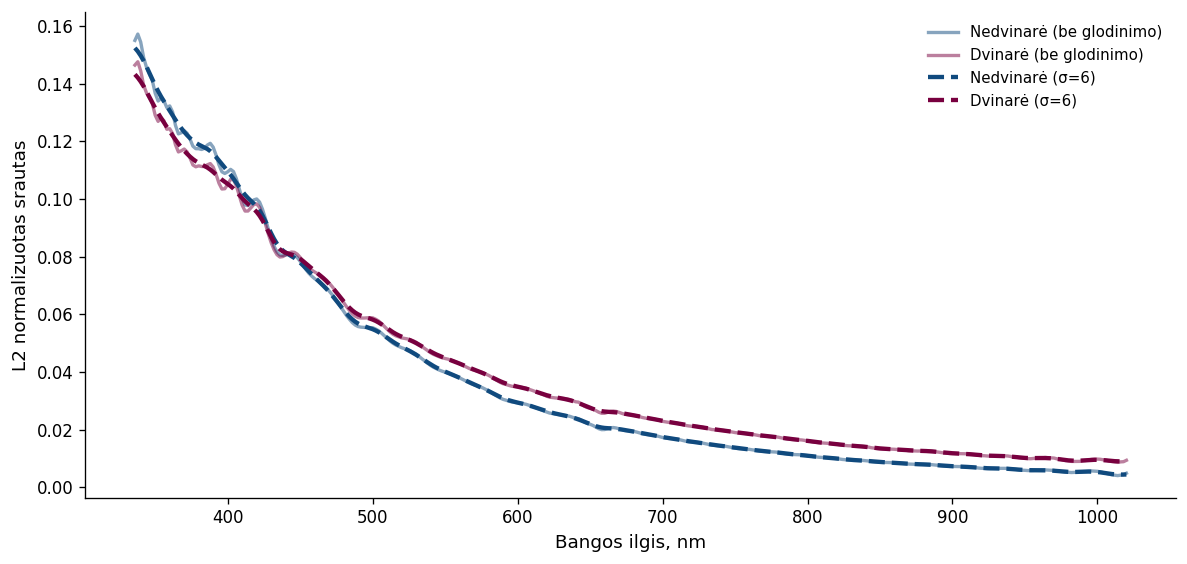

In [40]:
fig, ax = plt.subplots(figsize=(10, 4.8))

# RAW
ax.plot(
    wavelengths,
    mean_0_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    alpha=0.5,
    linestyle="-",
    label="Nedvinarė (be glodinimo)",
    zorder=2
)

ax.plot(
    wavelengths,
    mean_1_raw,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    alpha=0.5,
    linestyle="-",
    label="Dvinarė (be glodinimo)",
    zorder=2
)

# SMOOTHED 
ax.plot(
    wavelengths,
    mean_0_sm,
    color=COLOR_RAW,
    linewidth=2.6,
    linestyle="--",
    label="Nedvinarė (σ=6)",
    zorder=3
)

ax.plot(
    wavelengths,
    mean_1_sm,
    color=COLOR_SMOOTH,
    linewidth=2.6,
    linestyle="--",
    label="Dvinarė (σ=6)",
    zorder=3
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")

ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_class_mean_spectra_raw_vs_sigma6.svg", bbox_inches="tight")

plt.show()

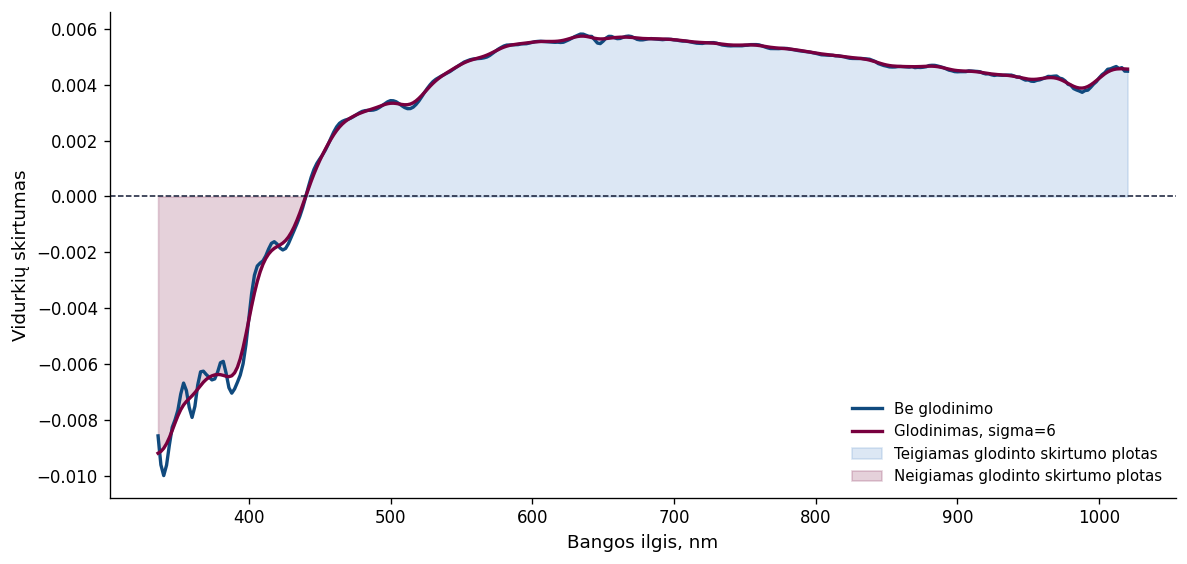

In [39]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    diff_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    diff_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label="Glodinimas, sigma=6",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    diff_sm,
    0,
    where=(diff_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas glodinto skirtumo plotas",
)

ax.fill_between(
    wavelengths,
    diff_sm,
    0,
    where=(diff_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas glodinto skirtumo plotas",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidurkių skirtumas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_mean_difference_raw_vs_sigma6.svg", bbox_inches="tight")
plt.show()



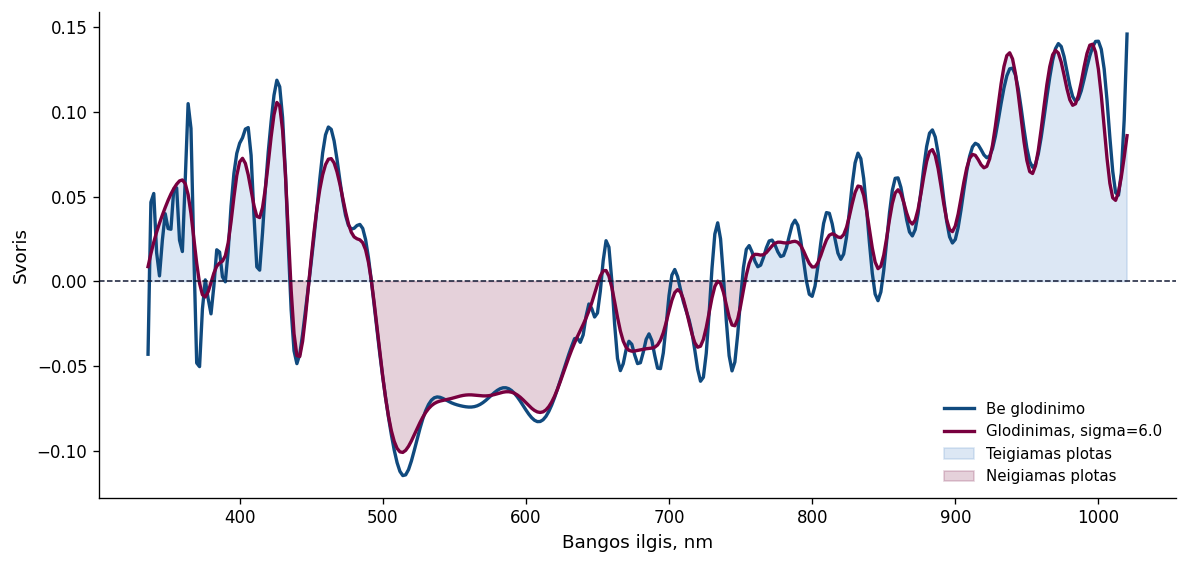

In [42]:
beta_logreg_raw = beta[(0.0, "logreg_l2")]
beta_logreg_sm = beta[(BEST_SIGMA, "logreg_l2")]

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_logreg_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    beta_logreg_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label=f"Glodinimas, sigma={BEST_SIGMA}",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    beta_logreg_sm,
    0,
    where=(beta_logreg_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas plotas",
)

ax.fill_between(
    wavelengths,
    beta_logreg_sm,
    0,
    where=(beta_logreg_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas plotas"
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="lower right")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(FIG_DIR / f"fig_weights_logreg_l2_raw_vs_sigma{BEST_SIGMA:g}.svg", bbox_inches="tight")
plt.show()



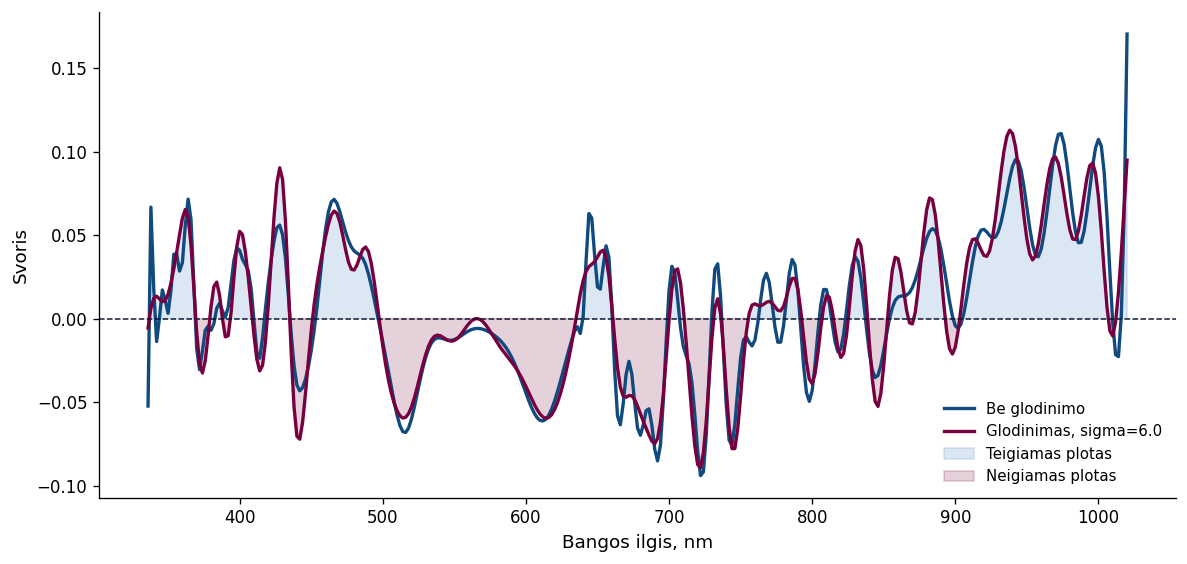

In [43]:
beta_svm_raw = beta[(0.0, "linear_svm")]
beta_svm_sm = beta[(BEST_SIGMA, "linear_svm")]

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_svm_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    beta_svm_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label=f"Glodinimas, sigma={BEST_SIGMA}",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    beta_svm_sm,
    0,
    where=(beta_svm_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas plotas"
)

ax.fill_between(
    wavelengths,
    beta_svm_sm,
    0,
    where=(beta_svm_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas plotas"
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="lower right")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(FIG_DIR / f"fig_weights_svm_raw_vs_sigma{BEST_SIGMA:g}.svg", bbox_inches="tight")
plt.show()



 ## 14. Save outputs

In [36]:
fold_path = OUT_DIR / "smoothing_fold_metrics.csv"
summary_path = OUT_DIR / "smoothing_summary.csv"
pretty_summary_path = OUT_DIR / "smoothing_summary_pretty.csv"
delta_path = OUT_DIR / "smoothing_delta_all_sigmas_minus_raw.csv"
wilcoxon_path = OUT_DIR / "smoothing_wilcoxon.csv"
payload_path = OUT_DIR / f"smoothing_interpretability_payload.npz"

df_fold.to_csv(fold_path, index=False)
df_summary.to_csv(summary_path, index=False)
pretty_summary.to_csv(pretty_summary_path, index=False)
df_delta.to_csv(delta_path, index=False)
df_wilcoxon.to_csv(wilcoxon_path, index=False)

print("Saved:")
print("-", fold_path)
print("-", summary_path)
print("-", pretty_summary_path)
print("-", delta_path)
print("-", wilcoxon_path)
print("-", payload_path)
print("-", FIG_DIR)



Saved:
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_fold_metrics.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_summary.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_summary_pretty.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_delta_all_sigmas_minus_raw.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_wilcoxon.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_interpretability_payload.npz
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing


 ## 15. Final view

In [21]:
print("\n=== SUMMARY ===")
display(pretty_summary)

print("\n=== DELTA: smoothed minus raw ===")
display(df_delta)

print("\n=== WILCOXON TESTS ===")
display(df_wilcoxon)


=== SUMMARY ===


,Sigma,Family,Method,F1 mean ± std,PR-AUC mean ± std,ROC-AUC mean ± std,Sensitivity mean ± std,Specificity mean ± std
0,0.0,Functional linear,Functional linear SVM,0.8066 ± 0.0300,0.8657 ± 0.0291,0.9151 ± 0.0197,0.8247 ± 0.0316,0.9453 ± 0.0149
1,2.0,Functional linear,Functional linear SVM,0.8090 ± 0.0302,0.8668 ± 0.0283,0.9158 ± 0.0191,0.8240 ± 0.0320,0.9470 ± 0.0156
2,4.0,Functional linear,Functional linear SVM,0.8064 ± 0.0283,0.8690 ± 0.0268,0.9178 ± 0.0181,0.8272 ± 0.0333,0.9443 ± 0.0141
3,6.0,Functional linear,Functional linear SVM,0.8086 ± 0.0294,0.8727 ± 0.0258,0.9209 ± 0.0172,0.8251 ± 0.0276,0.9464 ± 0.0150
4,0.0,Functional linear,Functional logistic regression (L2),0.8098 ± 0.0278,0.8650 ± 0.0280,0.9155 ± 0.0198,0.8292 ± 0.0329,0.9458 ± 0.0129
5,2.0,Functional linear,Functional logistic regression (L2),0.8097 ± 0.0291,0.8660 ± 0.0270,0.9161 ± 0.0190,0.8285 ± 0.0321,0.9459 ± 0.0137
6,4.0,Functional linear,Functional logistic regression (L2),0.8094 ± 0.0257,0.8690 ± 0.0261,0.9189 ± 0.0184,0.8288 ± 0.0312,0.9457 ± 0.0117
7,6.0,Functional linear,Functional logistic regression (L2),0.8109 ± 0.0273,0.8708 ± 0.0257,0.9205 ± 0.0177,0.8278 ± 0.0307,0.9470 ± 0.0131
8,0.0,Distance-based functional,weighted kNN + seuclidean,0.7738 ± 0.0274,0.8083 ± 0.0354,0.8910 ± 0.0201,0.7765 ± 0.0402,0.9429 ± 0.0145
9,2.0,Distance-based functional,weighted kNN + seuclidean,0.7826 ± 0.0298,0.8142 ± 0.0346,0.8973 ± 0.0199,0.7751 ± 0.0362,0.9491 ± 0.0128



=== DELTA: smoothed minus raw ===


,sigma,method,family,delta_pr_auc,delta_roc_auc,delta_sensitivity,delta_precision,delta_specificity,delta_accuracy,delta_f1,delta_youden_j
0,2.0,Functional linear SVM,Functional linear,0.001175,0.000719,-0.000721,0.005465,0.001727,0.001243,0.002397,0.001006
1,2.0,Functional logistic regression (L2),Functional linear,0.000999,0.000603,-0.000716,0.000552,0.000178,0.000000,-0.000054,-0.000538
2,2.0,weighted kNN + seuclidean,Distance-based functional,0.005910,0.006228,-0.001429,0.018415,0.006163,0.004654,0.008865,0.004734
3,4.0,Functional linear SVM,Functional linear,0.003333,0.002654,0.002490,-0.002456,-0.000933,-0.000249,-0.000125,0.001557
4,4.0,Functional logistic regression (L2),Functional linear,0.004000,0.003456,-0.000359,-0.000482,-0.000043,-0.000107,-0.000336,-0.000402
5,4.0,weighted kNN + seuclidean,Distance-based functional,0.017934,0.009796,0.012003,0.017036,0.004476,0.005968,0.014725,0.016479
6,6.0,Functional linear SVM,Functional linear,0.007080,0.005751,0.000352,0.003591,0.001107,0.000959,0.002070,0.001459
7,6.0,Functional logistic regression (L2),Functional linear,0.005765,0.004984,-0.001441,0.003504,0.001196,0.000675,0.001144,-0.000246
8,6.0,weighted kNN + seuclidean,Distance-based functional,0.020149,0.012310,0.007366,0.043464,0.013030,0.011901,0.025651,0.020397



=== WILCOXON TESTS ===


,sigma,method,metric,comparison,mean_raw,mean_smoothed,mean_delta,wilcoxon_statistic,p_value,statistically_significant,direction
0,2.0,Functional linear SVM,f1,sigma=2 vs raw,0.806558,0.808954,0.002397,339.0,3.399156e-01,False,improved
1,2.0,Functional linear SVM,pr_auc,sigma=2 vs raw,0.865662,0.866837,0.001175,171.0,1.547186e-06,True,improved
2,2.0,Functional logistic regression (L2),f1,sigma=2 vs raw,0.809755,0.809701,-0.000054,304.0,6.486728e-01,False,decreased
3,2.0,Functional logistic regression (L2),pr_auc,sigma=2 vs raw,0.865020,0.866019,0.000999,123.0,5.764963e-08,True,improved
4,2.0,weighted kNN + seuclidean,f1,sigma=2 vs raw,0.773768,0.782634,0.008865,269.0,1.068508e-03,True,improved
5,2.0,weighted kNN + seuclidean,pr_auc,sigma=2 vs raw,0.808304,0.814213,0.005910,260.0,1.628744e-04,True,improved
6,4.0,Functional linear SVM,f1,sigma=4 vs raw,0.806558,0.806433,-0.000125,521.0,8.312920e-01,False,decreased
7,4.0,Functional linear SVM,pr_auc,sigma=4 vs raw,0.865662,0.868995,0.003333,91.0,4.057499e-09,True,improved
8,4.0,Functional logistic regression (L2),f1,sigma=4 vs raw,0.809755,0.809419,-0.000336,546.0,6.666321e-01,False,decreased
9,4.0,Functional logistic regression (L2),pr_auc,sigma=4 vs raw,0.865020,0.869020,0.004000,51.0,6.337864e-11,True,improved
